In [11]:
# Use this if your running this on colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


# Load Data

In [14]:
DS_TRAIN = "/content/drive/MyDrive/Colab Notebooks/CMPE258_FinalProject/tft_ready_train.csv"
DS_TEST = "/content/drive/MyDrive/Colab Notebooks/CMPE258_FinalProject/tft_ready_test.csv"
DS_VAL = "/content/drive/MyDrive/Colab Notebooks/CMPE258_FinalProject/tft_ready_val.csv"

# Load CSV files
train = pd.read_csv(DS_TRAIN,parse_dates=["date"])
test = pd.read_csv(DS_TEST,parse_dates=["date"])
val = pd.read_csv(DS_VAL,parse_dates=["date"])

In [15]:
train.head()

,date,ticker,logvol_t,target_logvol_t+1,target_logvol_t+5,target_logvol_t+22,weekday,is_month_end,is_opex,is_holiday_eve,...,roll_std_ret_132d,roll_mean_vol_132d,roll_std_vol_132d,roll_mean_ret_252d,roll_std_ret_252d,roll_mean_vol_252d,roll_std_vol_252d,pca_vol_cs_1,pca_vol_cs_2,pca_vol_cs_3
0,2011-01-11,GLD,-5.070120,-5.174413,-4.311878,-3.344378,1,0,0,0,...,0.009368,0.006232,0.002946,0.000685,0.010444,0.006980,0.003172,-0.189073,0.922351,-0.811921
1,2011-01-12,GLD,-5.174413,-4.853728,-4.330529,-3.352055,2,0,0,0,...,0.009247,0.006234,0.002946,0.000792,0.010357,0.006945,0.003130,2.027990,1.011525,0.279239
2,2011-01-13,GLD,-4.853728,-4.963198,-4.457583,-3.374136,3,0,0,0,...,0.009214,0.006241,0.002943,0.000771,0.010345,0.006919,0.003113,0.666903,-0.005867,2.288776
3,2011-01-14,GLD,-4.963198,-5.450606,-4.434396,-3.371583,4,0,0,1,...,0.009257,0.006241,0.002943,0.000712,0.010367,0.006911,0.003109,2.124020,0.849803,0.386406
4,2011-01-18,GLD,-5.450606,-5.419435,-4.368734,-3.374667,1,0,0,0,...,0.009276,0.006262,0.002938,0.000713,0.010365,0.006900,0.003103,2.066790,0.059928,-0.236948


In [16]:
print(train.shape, val.shape, test.shape)

(7000, 43) (1972, 43) (4992, 43)


## Split Data

In [18]:

TARGET_COLS = ["target_logvol_t+1"]
ID_COLS = ["date", "ticker"]

exclude = ID_COLS + ["target_logvol_t+1", "target_logvol_t+5", "target_logvol_t+22"]
feature_cols = [c for c in train.columns if c not in exclude]

print("Number of features:", len(feature_cols))

scaler = StandardScaler().fit(train[feature_cols])

def transform_split(df):
    X = scaler.transform(df[feature_cols])
    y = df[TARGET_COLS].values.astype("float32")
    return X.astype("float32"), y

X_train, y_train = transform_split(train)
X_val,   y_val   = transform_split(val)
X_test,  y_test  = transform_split(test)

d_model = X_train.shape[1]
out_dim = len(TARGET_COLS)
print("d_model:", d_model, "| out_dim:", out_dim)

Number of features: 38
d_model: 38 | out_dim: 1


### Sequence Data

In [20]:

class PanelSequenceDataset(Dataset):
    def __init__(self, df, X, y, seq_len=64):
        self.df = df.copy().reset_index(drop=True)
        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.indices = []
        for _, g in self.df.groupby("ticker"):
            idx = g.index.to_numpy()
            for i in range(len(idx) - seq_len):
                start = idx[i]
                end = idx[i + seq_len]
                self.indices.append((start, end))
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        start, end = self.indices[i]
        seq_slice = slice(start, end)
        x_seq = self.X[seq_slice]
        y_t  = self.y[end]
        return torch.from_numpy(x_seq), torch.from_numpy(y_t)

SEQ_LEN = 64
BATCH_SIZE = 64

train_ds = PanelSequenceDataset(train, X_train, y_train, seq_len=SEQ_LEN)
val_ds   = PanelSequenceDataset(val,   X_val,   y_val,   seq_len=SEQ_LEN)
test_ds  = PanelSequenceDataset(test,  X_test,  y_test,  seq_len=SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Num train sequences:", len(train_ds))
print("Num val sequences:  ", len(val_ds))
print("Num test sequences: ", len(test_ds))


Num train sequences: 6744
Num val sequences:   1716
Num test sequences:  4736


# Informer Model

In [21]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

In [22]:

class InformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x, attn_mask=None):
        attn_out, _ = self.self_attn(x, x, x, attn_mask=attn_mask)
        x = self.norm1(x + self.dropout1(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout2(ff_out))
        return x


In [23]:

class SimpleInformer(nn.Module):
    def __init__(self, d_model, out_dim, n_heads=4, d_ff=256, n_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(d_model, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            InformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, out_dim)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x)
        last = x[:, -1, :]
        out = self.head(last)
        return out


## Train

In [26]:

model = SimpleInformer(d_model=d_model, out_dim=out_dim, n_heads=2, d_ff=256, n_layers=3, dropout=0.1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

def eval_loader(loader):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            all_y.append(yb.cpu().numpy())
            all_p.append(pred.cpu().numpy())
    y = np.concatenate(all_y, axis=0).squeeze()
    p = np.concatenate(all_p, axis=0).squeeze()
    mse = mean_squared_error(y, p)
    rmse = np.sqrt(mse)
    v_true = np.exp(2 * y)
    v_pred = np.exp(2 * p)
    qlike = np.mean(np.log(v_pred) + v_true / v_pred)
    return rmse, qlike

N_EPOCHS = 50
best_val_rmse = float("inf")
best_state = None
history = {"train_loss": [], "val_rmse": [], "val_qlike": []}

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n_samples = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred.squeeze(), yb.squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)
    train_loss = running_loss / max(n_samples, 1)
    val_rmse, val_qlike = eval_loader(val_loader)
    history["train_loss"].append(train_loss)
    history["val_rmse"].append(val_rmse)
    history["val_qlike"].append(val_qlike)
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_RMSE={val_rmse:.4f} | val_QLIKE={val_qlike:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)

test_rmse, test_qlike = eval_loader(test_loader)
print("\nBest validation RMSE:", best_val_rmse)
print("Test RMSE:", test_rmse)
print("Test QLIKE:", test_qlike)


Epoch 001 | train_loss=2.0460 | val_RMSE=0.4285 | val_QLIKE=-9.1600
Epoch 002 | train_loss=0.2162 | val_RMSE=0.4372 | val_QLIKE=-9.3625
Epoch 003 | train_loss=0.2127 | val_RMSE=0.4217 | val_QLIKE=-9.2721
Epoch 004 | train_loss=0.2035 | val_RMSE=0.4115 | val_QLIKE=-9.3175
Epoch 005 | train_loss=0.1999 | val_RMSE=0.4195 | val_QLIKE=-9.2220
Epoch 006 | train_loss=0.2047 | val_RMSE=0.4436 | val_QLIKE=-9.0655
Epoch 007 | train_loss=0.2022 | val_RMSE=0.4131 | val_QLIKE=-9.2441
Epoch 008 | train_loss=0.1960 | val_RMSE=0.4208 | val_QLIKE=-9.3757
Epoch 009 | train_loss=0.1938 | val_RMSE=0.4358 | val_QLIKE=-9.1185
Epoch 010 | train_loss=0.1984 | val_RMSE=0.4067 | val_QLIKE=-9.3220
Epoch 011 | train_loss=0.1912 | val_RMSE=0.4335 | val_QLIKE=-9.1159
Epoch 012 | train_loss=0.1934 | val_RMSE=0.4140 | val_QLIKE=-9.2569
Epoch 013 | train_loss=0.1878 | val_RMSE=0.4138 | val_QLIKE=-9.3558
Epoch 014 | train_loss=0.1929 | val_RMSE=0.4085 | val_QLIKE=-9.3258
Epoch 015 | train_loss=0.1880 | val_RMSE=0.4133 

In [28]:
import copy
from torch.utils.data import DataLoader

# 8. Permutation feature importance on validation set

# Baseline performance on validation data
base_val_rmse, base_val_qlike = eval_loader(val_loader)
print(f"Baseline val RMSE = {base_val_rmse:.4f}, QLIKE = {base_val_qlike:.4f}")

feature_importance = {}

# We'll reuse the same seed for reproducibility
rng = np.random.default_rng(42)

for j, feat in enumerate(feature_cols):
    # Make a permuted copy of X_val ONLY for this feature
    X_val_perm = X_val.copy()

    # Shuffle this feature's column across all validation rows
    col = X_val_perm[:, j].copy()
    rng.shuffle(col)
    X_val_perm[:, j] = col

    # Build a new Dataset & DataLoader with the permuted features
    val_ds_perm = PanelSequenceDataset(val, X_val_perm, y_val, seq_len=SEQ_LEN)
    val_loader_perm = DataLoader(val_ds_perm, batch_size=BATCH_SIZE,
                                 shuffle=False, drop_last=False)

    # Evaluate model performance with this feature destroyed
    rmse_perm, qlike_perm = eval_loader(val_loader_perm)

    # Increase in RMSE compared to baseline is our importance score
    delta_rmse = rmse_perm - base_val_rmse
    feature_importance[feat] = delta_rmse

    print(f"Feature: {feat:30s} | ΔRMSE = {delta_rmse:+.5f}")


Baseline val RMSE = 0.4044, QLIKE = -9.3479
Feature: logvol_t                       | ΔRMSE = +0.02774
Feature: weekday                        | ΔRMSE = +0.00150
Feature: is_month_end                   | ΔRMSE = +0.00076
Feature: is_opex                        | ΔRMSE = +0.00519
Feature: is_holiday_eve                 | ΔRMSE = +0.00773
Feature: dow_sin                        | ΔRMSE = +0.00755
Feature: dow_cos                        | ΔRMSE = +0.00326
Feature: vix                            | ΔRMSE = +0.00310
Feature: vix3m                          | ΔRMSE = +0.00216
Feature: vix_term_spread                | ΔRMSE = +0.01004
Feature: ret_1d                         | ΔRMSE = +0.00300
Feature: cross_vol_rank                 | ΔRMSE = +0.00602
Feature: logvol_t-1                     | ΔRMSE = +0.00247
Feature: logvol_t-5                     | ΔRMSE = +0.00289
Feature: logvol_t-22                    | ΔRMSE = +0.00204
Feature: roll_mean_ret_5d               | ΔRMSE = -0.00115
Feature: rol

In [29]:
# Sort by importance (largest increase in RMSE first)
sorted_items = sorted(feature_importance.items(),
                      key=lambda x: x[1],
                      reverse=True)

top_k = 20
top_feats = sorted_items[:top_k]

print("\\nTop features by ΔRMSE:")
for name, score in top_feats:
    print(f"{name:30s}  ΔRMSE = {score:+.5f}")


\nTop features by ΔRMSE:
roll_mean_vol_252d              ΔRMSE = +0.04410
logvol_t                        ΔRMSE = +0.02774
roll_mean_vol_22d               ΔRMSE = +0.01134
roll_std_ret_252d               ΔRMSE = +0.01020
vix_term_spread                 ΔRMSE = +0.01004
roll_std_ret_132d               ΔRMSE = +0.00904
roll_mean_vol_5d                ΔRMSE = +0.00889
roll_std_ret_66d                ΔRMSE = +0.00813
is_holiday_eve                  ΔRMSE = +0.00773
roll_mean_vol_132d              ΔRMSE = +0.00758
dow_sin                         ΔRMSE = +0.00755
roll_mean_ret_252d              ΔRMSE = +0.00697
cross_vol_rank                  ΔRMSE = +0.00602
roll_mean_vol_66d               ΔRMSE = +0.00533
is_opex                         ΔRMSE = +0.00519
roll_std_ret_22d                ΔRMSE = +0.00414
roll_std_vol_132d               ΔRMSE = +0.00412
roll_std_ret_5d                 ΔRMSE = +0.00401
roll_std_vol_252d               ΔRMSE = +0.00365
dow_cos                         ΔRMSE = +0.0

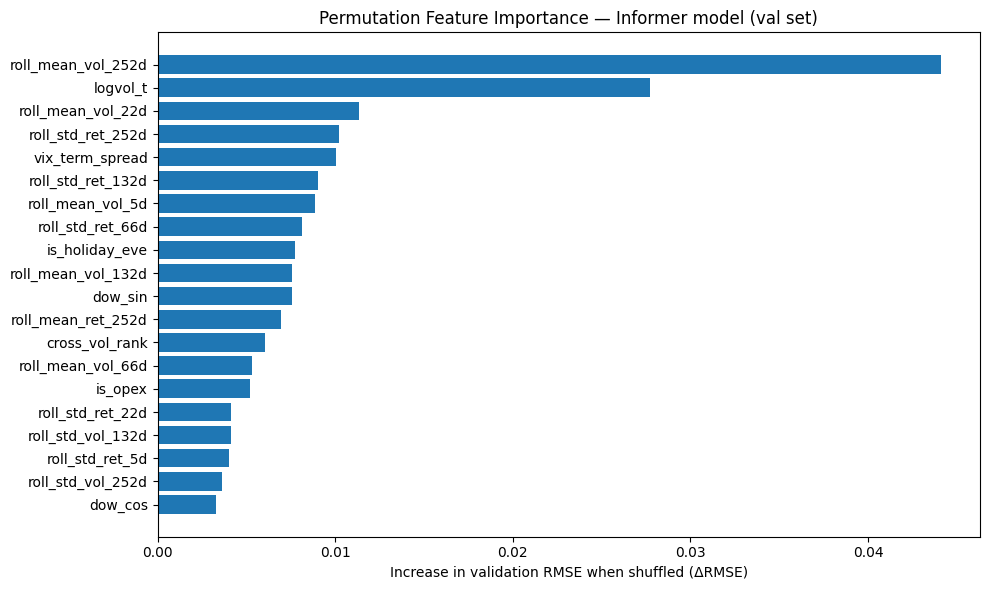

In [30]:
names = [x[0] for x in top_feats]
scores = [x[1] for x in top_feats]

plt.figure(figsize=(10, 6))
plt.barh(names[::-1], scores[::-1])  # reverse for top at top
plt.xlabel("Increase in validation RMSE when shuffled (ΔRMSE)")
plt.title("Permutation Feature Importance — Informer model (val set)")
plt.tight_layout()
plt.show()
